# NYC trip duration

This EDA for ***New York City Taxi Trip Duration*** project inspired by kaggle competition to predict the total duration for taxi driving in New York  
  
  
  
* from Kaggle  

***id*** - a unique identifier for each trip
  
***vendor_id*** - a code indicating the provider associated with the trip record  

***pickup_datetime*** - date and time when the trip was started

***dropoff_datetime*** - date and time when the meter was disengaged  

***passenger_count*** - the number of passengers in the vehicle (driver entered value)  

***pickup_longitude*** - the longitude where the meter was engaged  

***pickup_latitude*** - the latitude where the meter was engaged  

***dropoff_longitude*** - the longitude where the meter was disengaged  

***dropoff_latitude*** - the latitude where the meter was disengaged  

***store_and_fwd_flag*** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - N (No) → Data was sent to the server instantly in real time 
Y (Yes) → No connection was available, so the data was saved in the taxi's memory and sent later when connection was restored

***trip_duration*** - duration of the trip in seconds

In [494]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [495]:
df = pd.read_csv("../data/train.csv")

In [496]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [497]:
df.head(20)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,id1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,id1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,id0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [498]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


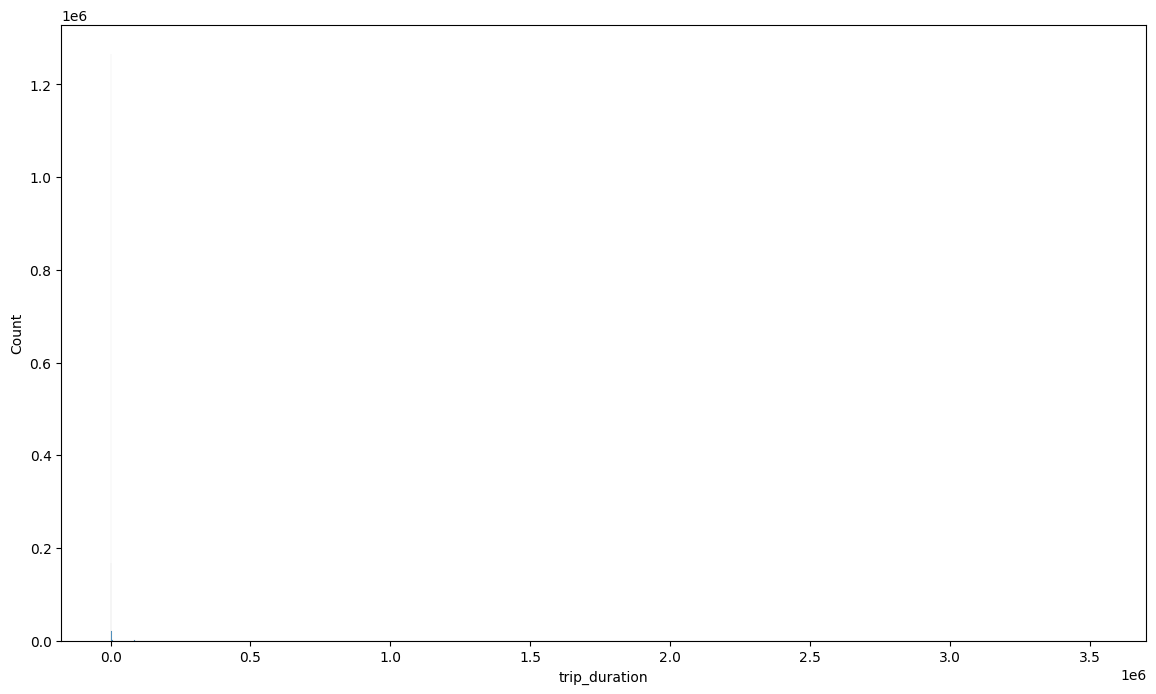

In [499]:
plt.figure(figsize = (14,8))

sns.histplot(df["trip_duration"])

plt.show()

### As we see the mean values of ***pickup lat,long and drop of lat and long*** has the same value so i want to investigate the starting point and the ending of sample of trips

In [500]:
import folium


# Take a sample to avoid browser crash (adjust as needed)
sample = df.sample(500, random_state=42)

# Create map centered on NYC
m = folium.Map(location=[40.75, -73.98], zoom_start=12)

for _, row in sample.iterrows():
    pickup = [row['pickup_latitude'], row['pickup_longitude']]
    dropoff = [row['dropoff_latitude'], row['dropoff_longitude']]
    
    # Draw line between pickup and dropoff
    folium.PolyLine(
        locations=[pickup, dropoff],
        color='blue',
        weight=1,
        opacity=0.5
    ).add_to(m)
    
    # Pickup point (green)
    folium.CircleMarker(
        location=pickup,
        radius=3,
        color='green',
        fill=True,
        fill_opacity=0.7,
        tooltip='Pickup'
    ).add_to(m)
    
    # Dropoff point (red)
    folium.CircleMarker(
        location=dropoff,
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7,
        tooltip='Dropoff'
    ).add_to(m)

# Save to file
m.save('trips_map.html')
print("Map saved!")

Map saved!


In [501]:
import pydeck as pdk

layer = pdk.Layer(
    "ArcLayer",
    data=sample,
    get_source_position=["pickup_longitude", "pickup_latitude"],
    get_target_position=["dropoff_longitude", "dropoff_latitude"],
    get_source_color=[0, 255, 0],   # green = pickup
    get_target_color=[255, 0, 0],   # red = dropoff
    width_scale=0.5,
    auto_highlight=True,
)

view = pdk.ViewState(latitude=40.75, longitude=-73.98, zoom=11)
pdk.Deck(layers=[layer], initial_view_state=view).to_html('map.html')

### Most of The trips is in the same range of lat and long values  ***note: if you can't see the map, the map in the same folder "notebooks"***  

In [502]:
df["passenger_count"].value_counts()

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64

### In ***passenger_count*** we aren't interested when the driver hasn't passenger ***=0*** and [7,8,9] is just outlier so i will drop it 

In [503]:
df = df[df["passenger_count"].between(1,6)]

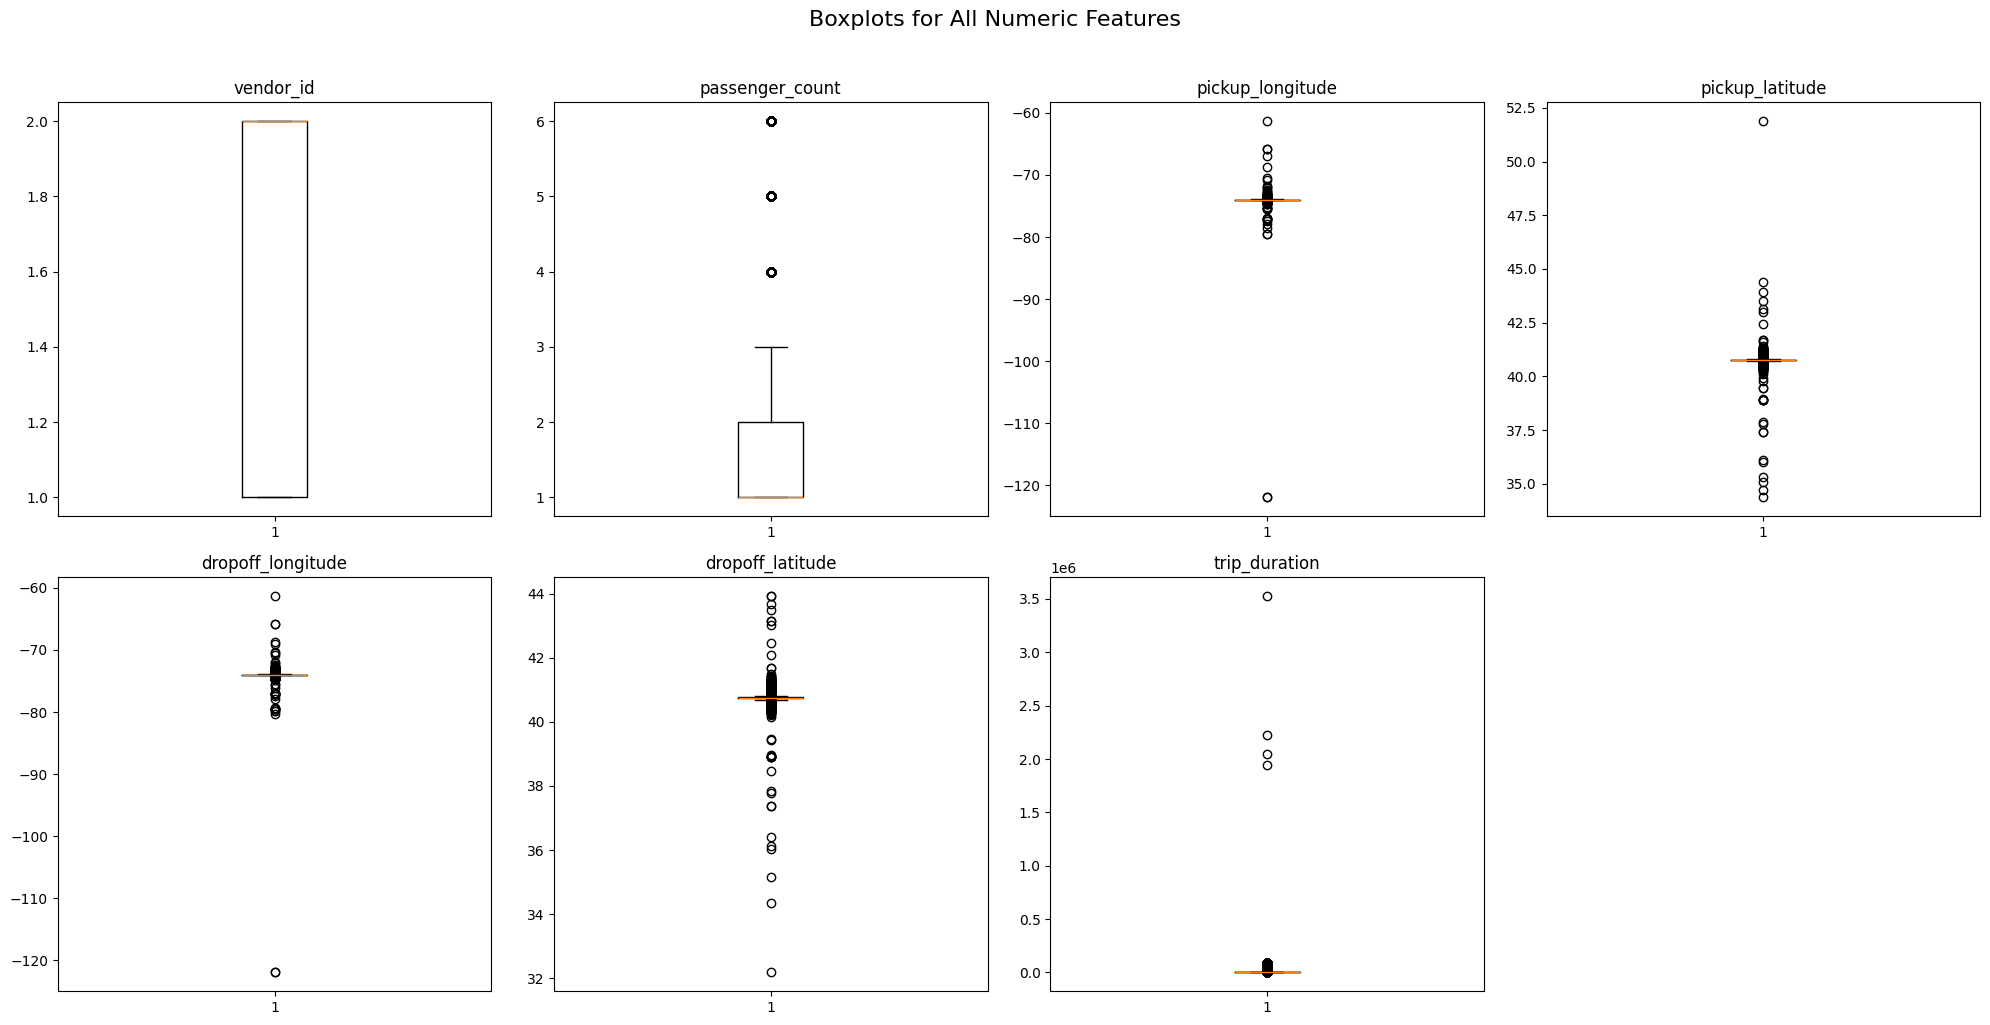

In [504]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=12)
    


axes[-1].set_visible(False)

plt.suptitle('Boxplots for All Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### ***vendor_id*** it has two vendors 1 and 2 
### ***passenger_count*** i will keep the values of it and don't consider from [2,6] as outlier because it has a decent number of trips
### ***all latitude and longitude*** have outlier values ***After searching i found that the latitude and longitude range of NewYork City is lat_min, lat_max = 40.4774, 40.9176 and lon_min, lon_max = -74.2591, -73.7004***  
### ***trip_duration*** has outlier value but i will fix the latitude and logitude first 


In [505]:
# New York City boundaries
lat_min, lat_max = 40.4774, 40.9176
lon_min, lon_max = -74.2591, -73.7004 

df = df[
    (df['pickup_latitude'].between(lat_min, lat_max)) &
    (df['pickup_longitude'].between(lon_min, lon_max)) &
    (df['dropoff_latitude'].between(lat_min, lat_max)) &
    (df['dropoff_longitude'].between(lon_min, lon_max))
]

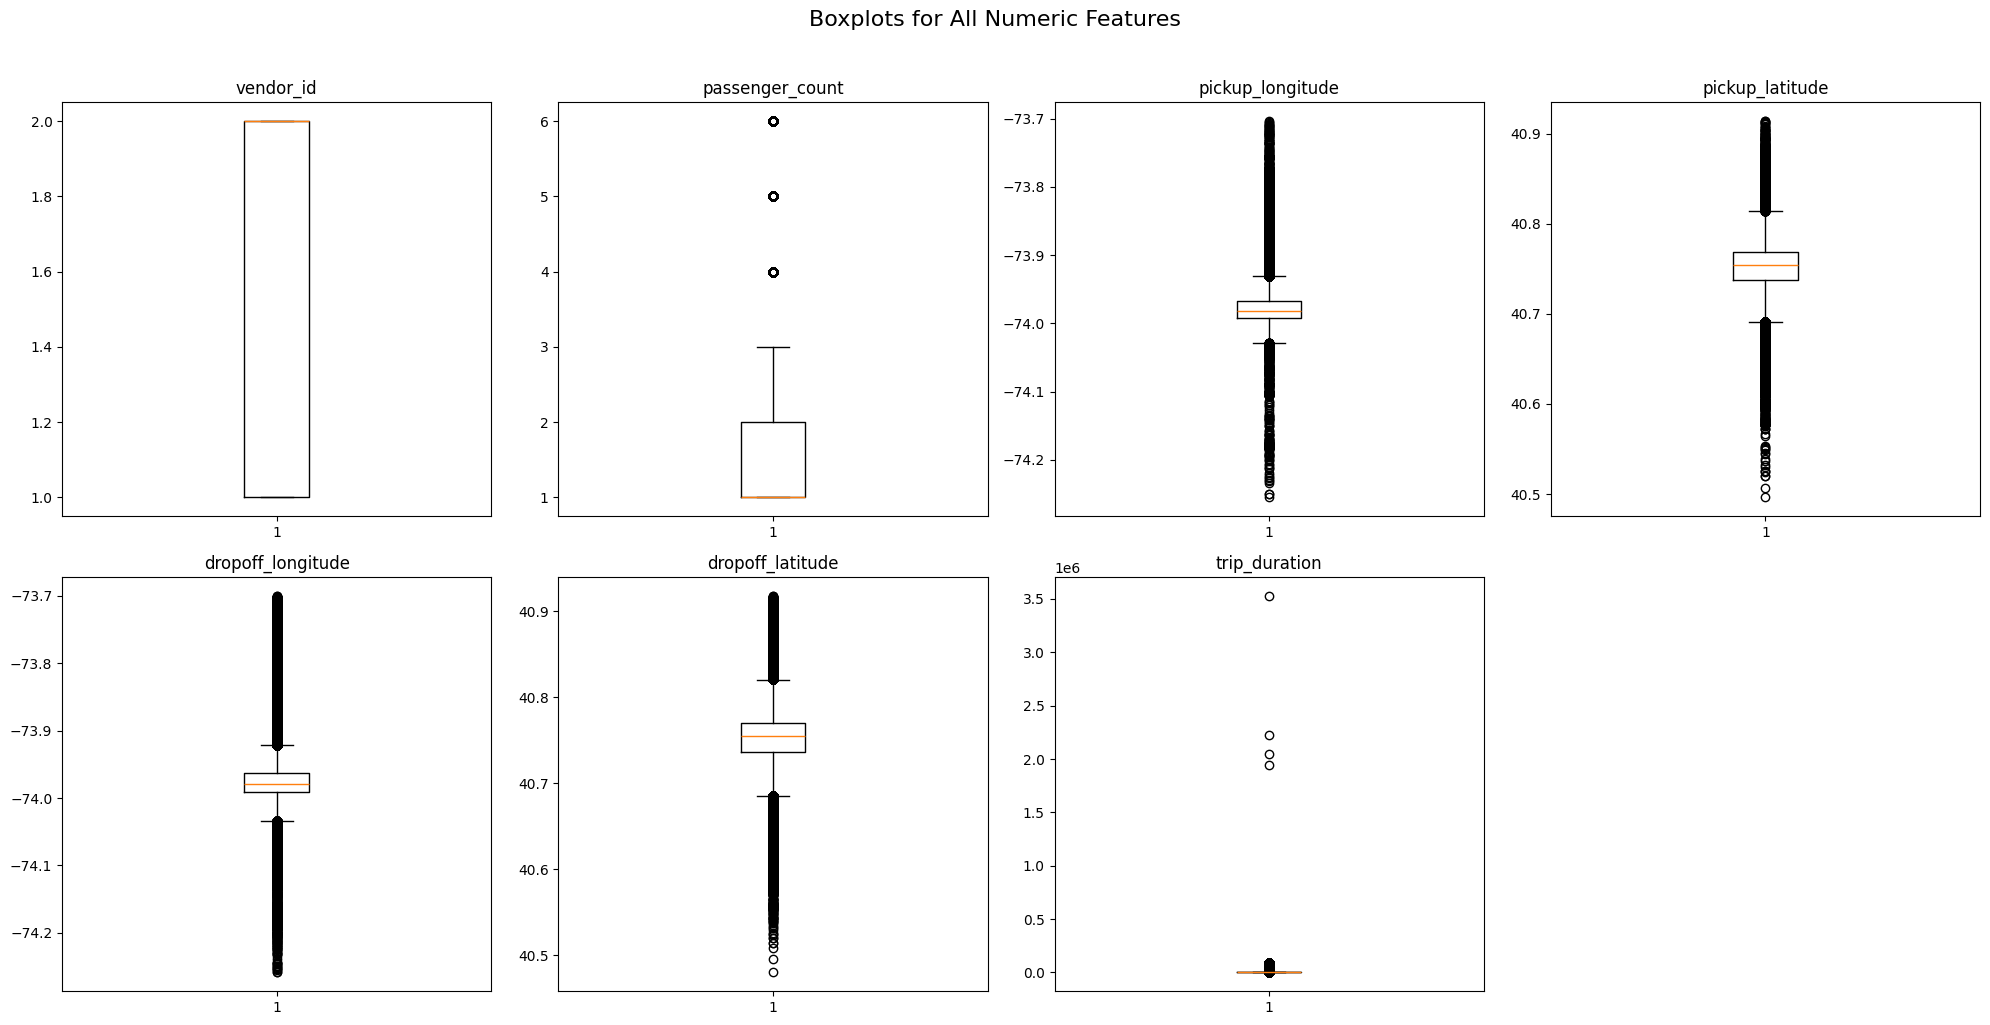

In [506]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=12)
    


axes[-1].set_visible(False)

plt.suptitle('Boxplots for All Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### ***trip_duration*** still has outlier values

### create a map to see the difference and it's called ***trip_2_map.html

In [507]:
import folium


# Take a sample to avoid browser crash (adjust as needed)
sample = df.sample(500, random_state=42)

# Create map centered on NYC
m = folium.Map(location=[40.75, -73.98], zoom_start=12)

for _, row in sample.iterrows():
    pickup = [row['pickup_latitude'], row['pickup_longitude']]
    dropoff = [row['dropoff_latitude'], row['dropoff_longitude']]
    
    # Draw line between pickup and dropoff
    folium.PolyLine(
        locations=[pickup, dropoff],
        color='blue',
        weight=1,
        opacity=0.5
    ).add_to(m)
    
    # Pickup point (green)
    folium.CircleMarker(
        location=pickup,
        radius=3,
        color='green',
        fill=True,
        fill_opacity=0.7,
        tooltip='Pickup'
    ).add_to(m)
    
    # Dropoff point (red)
    folium.CircleMarker(
        location=dropoff,
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7,
        tooltip='Dropoff'
    ).add_to(m)

# Save to file
m.save('trips_2_map.html')
print("Map saved!")

Map saved!


### apply lower and upper fence

In [508]:
q1 = df["trip_duration"].quantile(0.25)
q3 = df["trip_duration"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 2 * iqr
upper = q3 + 2 * iqr
 

df = df[(df["trip_duration"] >= lower) & (df["trip_duration"] <= upper)]

{'whiskers': [<matplotlib.lines.Line2D at 0x7d403e575820>,
 'caps': [<matplotlib.lines.Line2D at 0x7d403f907f80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d403e5778c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d403f906060>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d403f905d00>],
 'means': []}

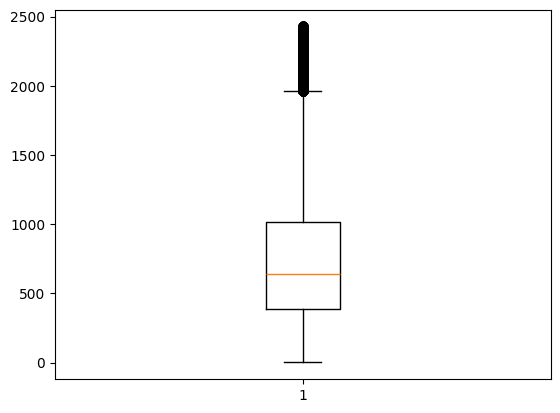

In [509]:
plt.boxplot(df["trip_duration"])

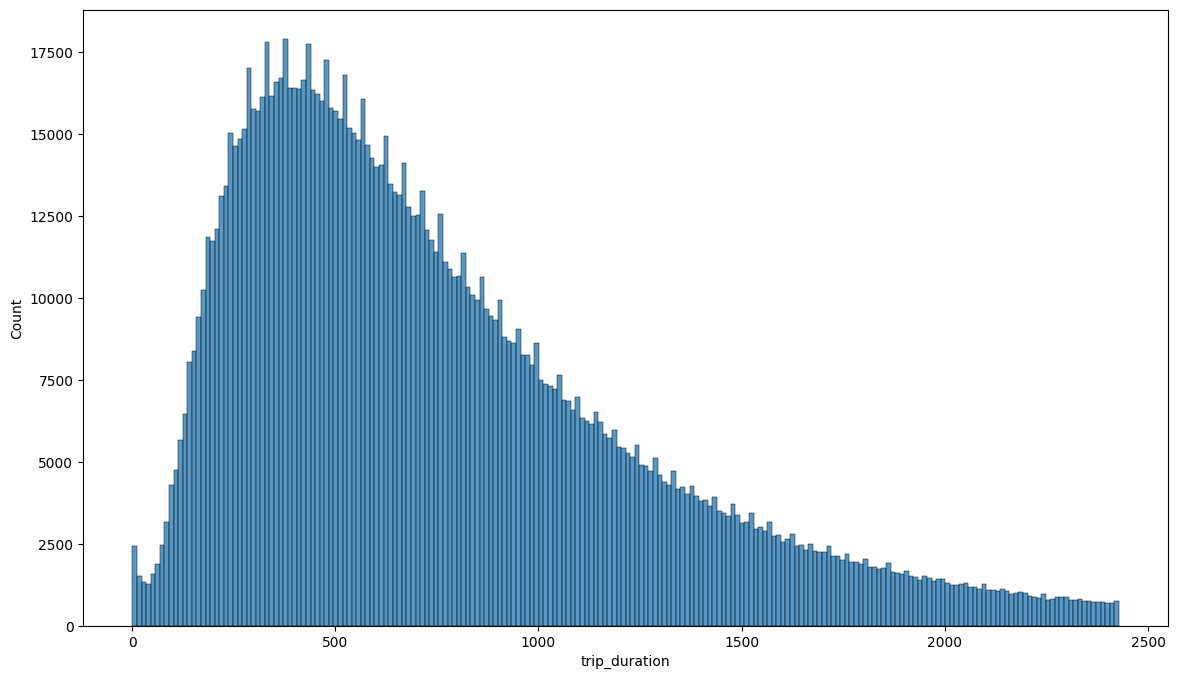

In [510]:
plt.figure(figsize = (14,8))

sns.histplot(df["trip_duration"])

plt.show()

In [511]:
df["trip_duration"].describe()

count    1.410025e+06
mean     7.598870e+02
std      4.888884e+02
min      1.000000e+00
25%      3.890000e+02
50%      6.420000e+02
75%      1.019000e+03
max      2.428000e+03
Name: trip_duration, dtype: float64

In [512]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1410025 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1410025 non-null  object 
 1   vendor_id           1410025 non-null  int64  
 2   pickup_datetime     1410025 non-null  object 
 3   dropoff_datetime    1410025 non-null  object 
 4   passenger_count     1410025 non-null  int64  
 5   pickup_longitude    1410025 non-null  float64
 6   pickup_latitude     1410025 non-null  float64
 7   dropoff_longitude   1410025 non-null  float64
 8   dropoff_latitude    1410025 non-null  float64
 9   store_and_fwd_flag  1410025 non-null  object 
 10  trip_duration       1410025 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 129.1+ MB


### See again the box plot of all values

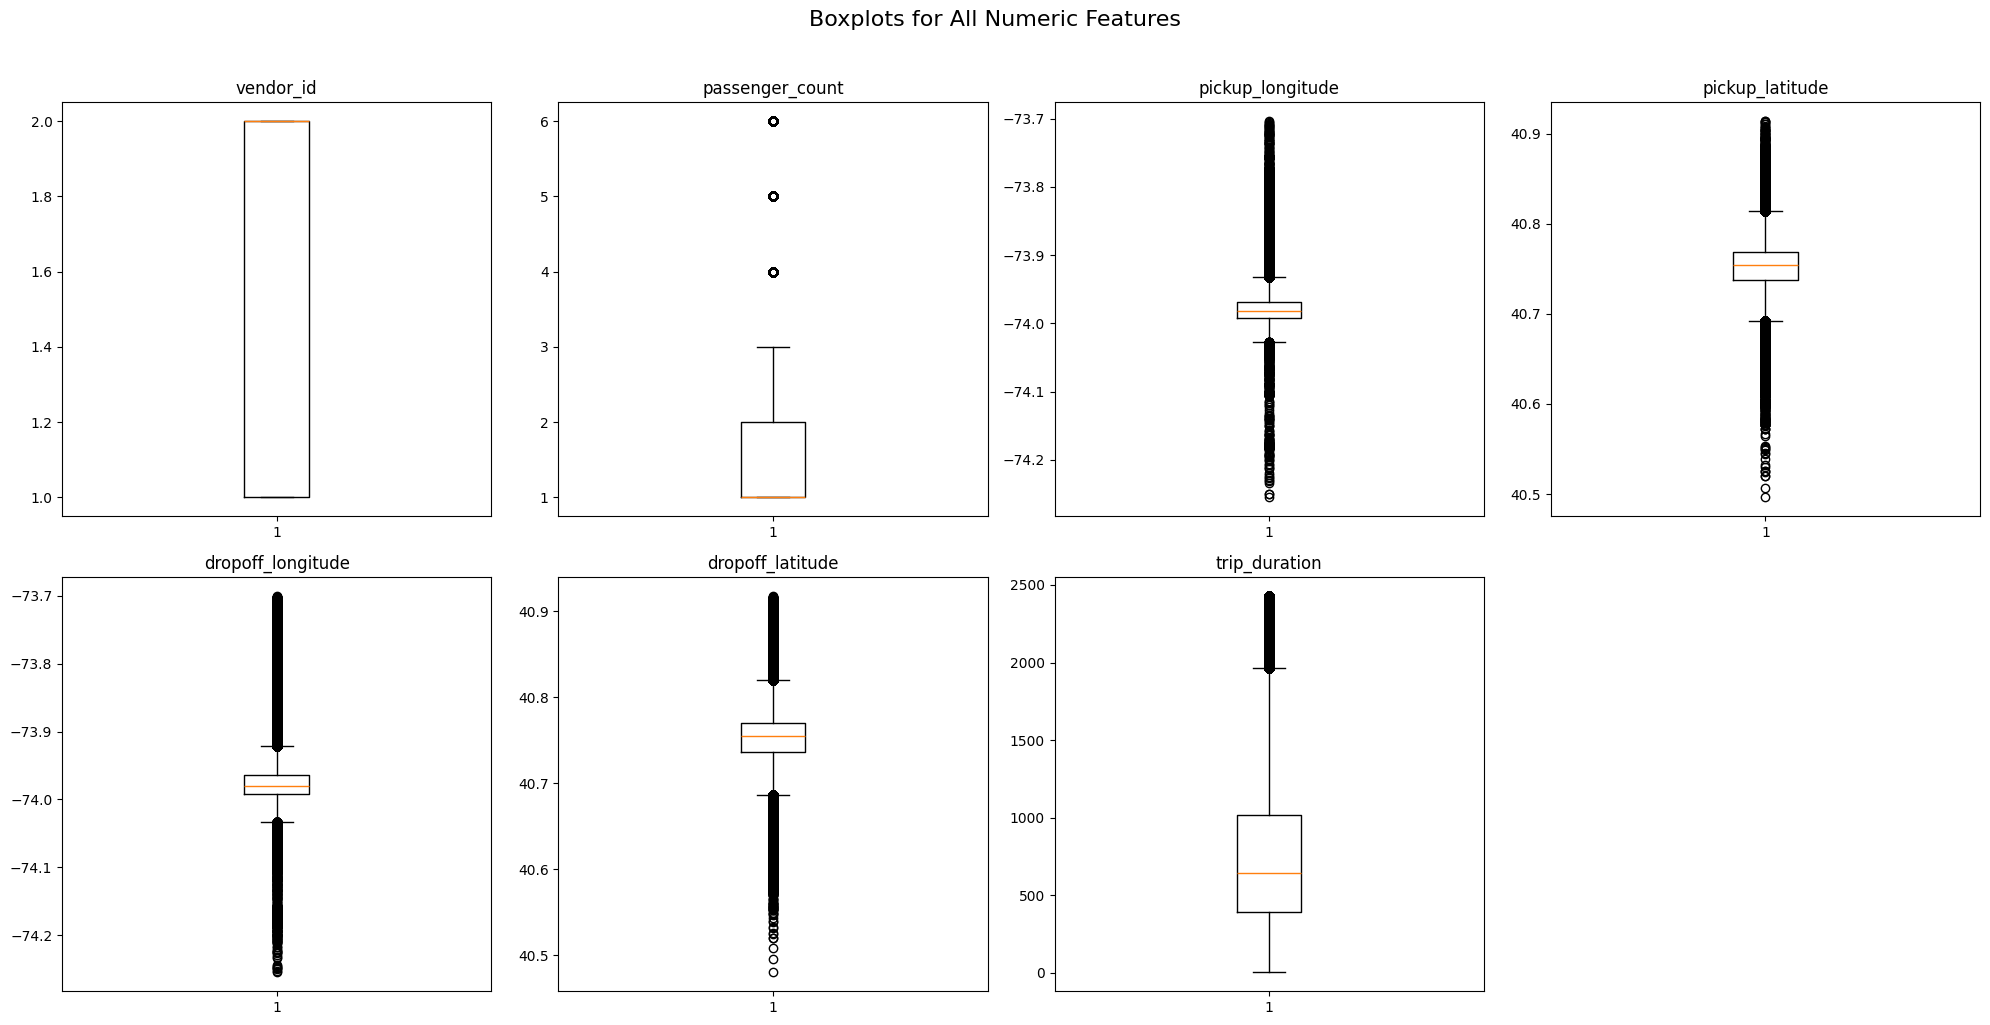

In [513]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=12)
    


axes[-1].set_visible(False)

plt.suptitle('Boxplots for All Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Just checking the correlation matrix

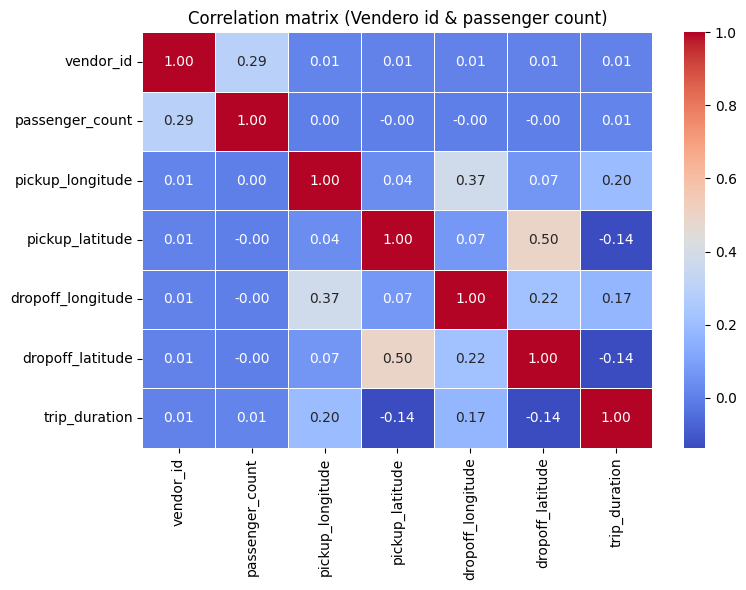

In [514]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']
feats = df[cols]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix (Vendero id & passenger count)")
plt.tight_layout()
plt.show()

### We scale the trip_duration by taking the log

In [515]:
 df["log_trip_duration"]= np.log(df["trip_duration"])

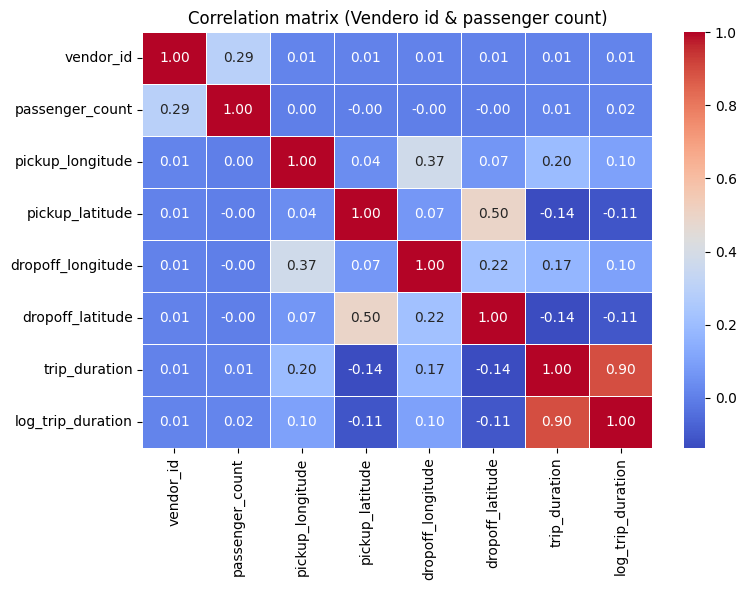

In [516]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration','log_trip_duration']
feats = df[cols]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix (Vendero id & passenger count)")
plt.tight_layout()
plt.show()

### We will calculate the distance by latitude and longitude by using ***Haversin formula***

In [517]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(np.radians, [lat1,lon1, lat2, lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2) * (np.sin(dlon/2)**2)

    d = 2*R*np.arcsin(np.sqrt(a))
    return d

df['haversine_distance'] = haversine(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
df['haversine_distance'].head()



0    1.498521
1    1.805507
2    6.385098
3    1.485498
4    1.188588
Name: haversine_distance, dtype: float64

### Checking correlation

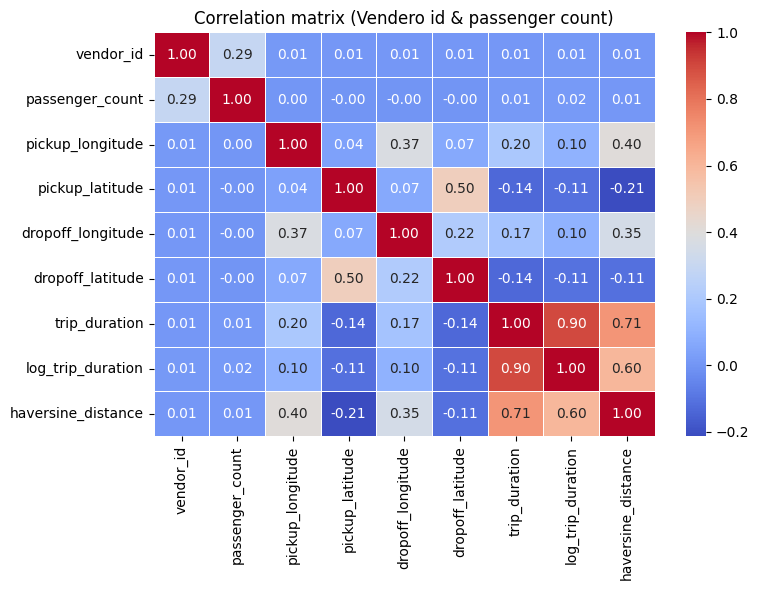

In [518]:
cols = ['vendor_id', 'passenger_count', 'pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration','log_trip_duration','haversine_distance']
feats = df[cols]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix (Vendero id & passenger count)")
plt.tight_layout()

### Convert ***pickup_time*** to date_time

In [519]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
print(df['pickup_datetime'].dtype)

datetime64[ns]


In [520]:
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['hour'] = df['pickup_datetime'].dt.hour
df['day_name'] = df['pickup_datetime'].dt.day_name()
print(df[['year','month', 'day_of_week', 'hour', 'day_name']].head(10))

   year  month  day_of_week  hour   day_name
0  2016      3            0    17     Monday
1  2016      6            6     0     Sunday
2  2016      1            1    11    Tuesday
3  2016      4            2    19  Wednesday
4  2016      3            5    13   Saturday
5  2016      1            5    22   Saturday
6  2016      6            4    22     Friday
7  2016      5            5     7   Saturday
8  2016      5            4    23     Friday
9  2016      3            3    21   Thursday


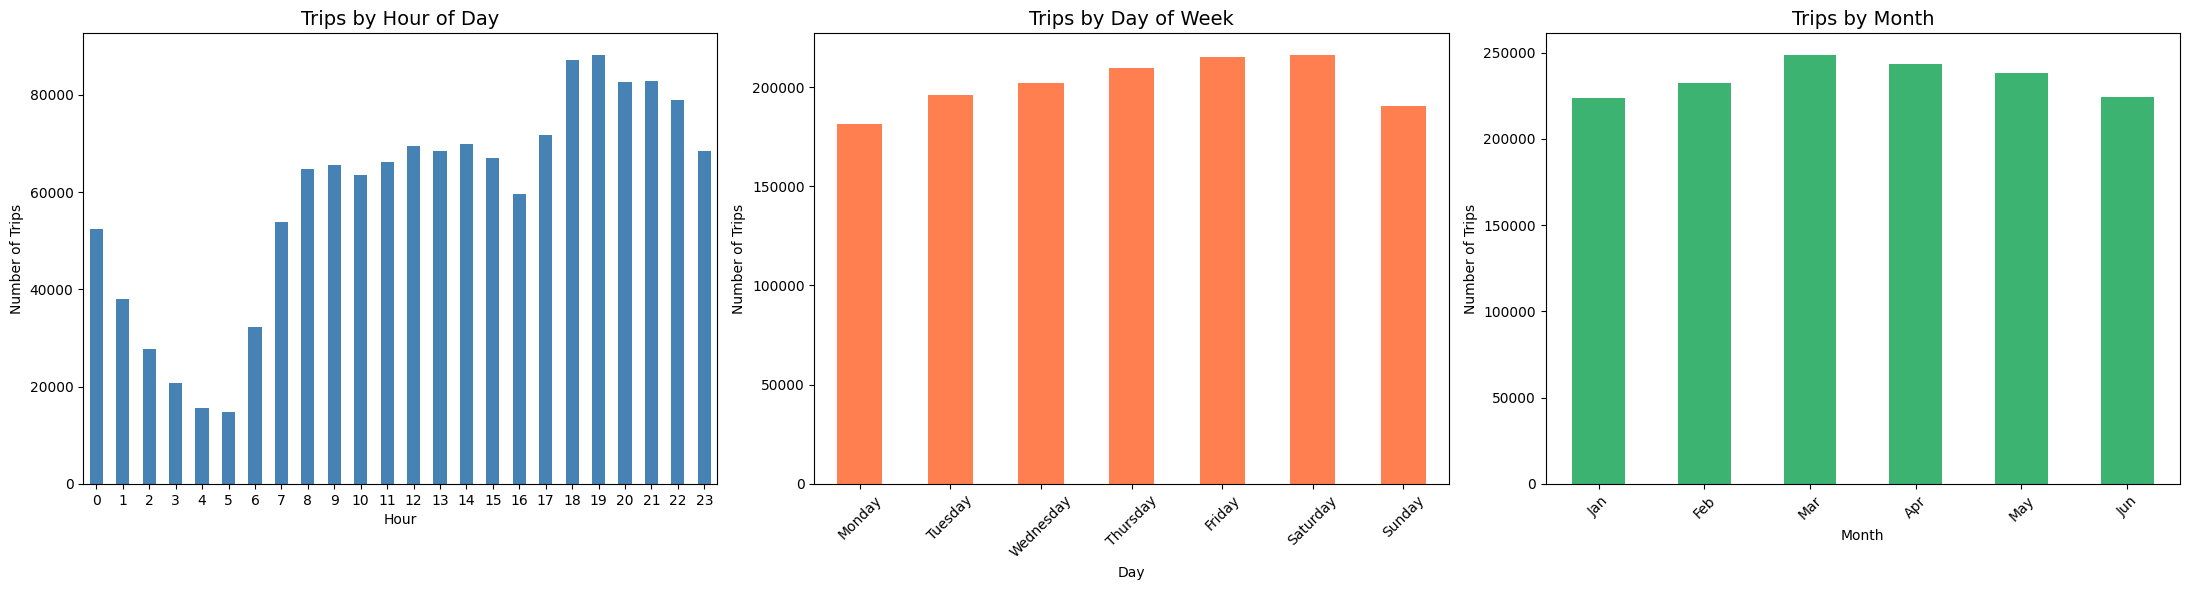

In [521]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Most frequent hours
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trips by Hour of Day', fontsize=14)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Trips')
axes[0].tick_params(axis='x', rotation=0)

# Most frequent day names
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Trips by Day of Week', fontsize=14)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=45)

# Most frequent months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Trips by Month', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticklabels(month_order[:df['month'].nunique()], rotation=45)

plt.tight_layout()
plt.show()

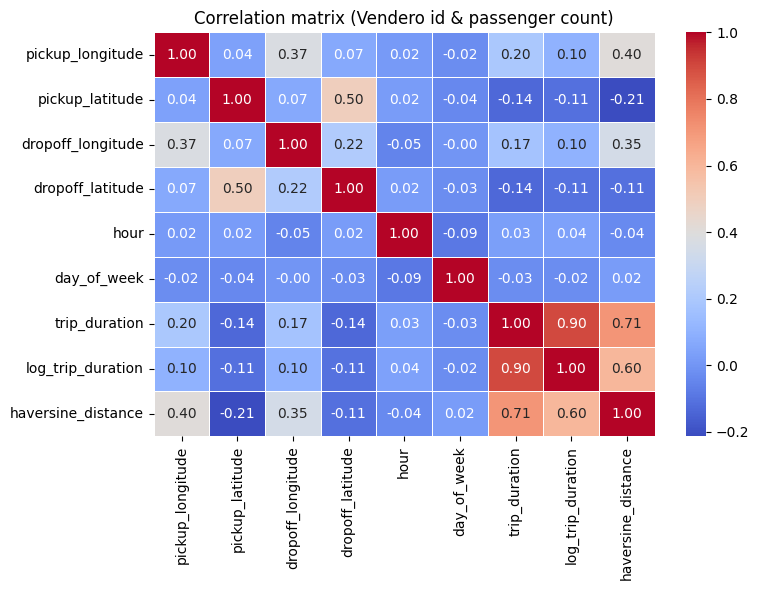

In [522]:
cols = ['pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude','hour','day_of_week', 'trip_duration','log_trip_duration','haversine_distance']
feats = df[cols]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix (Vendero id & passenger count)")
plt.tight_layout()

### Drop useless colmuns

In [523]:
drop_cols = ['log_trip_duration','id' , 'day_of_week']

df = df.drop(drop_cols,axis = 1)

In [524]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,haversine_distance,year,month,hour,day_name
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,2016,3,17,Monday
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,2016,6,0,Sunday
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,2016,1,11,Tuesday
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,2016,4,19,Wednesday
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,2016,3,13,Saturday


In [525]:
drop_cols = ['pickup_datetime', 'dropoff_datetime', 
             'store_and_fwd_flag', 'year', 'day_name']

df = df.drop(columns=drop_cols)


In [526]:
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,haversine_distance,month,hour
0,2,1,-73.982155,40.767937,-73.964630,40.765602,455,1.498521,3,17
1,1,1,-73.980415,40.738564,-73.999481,40.731152,663,1.805507,6,0
2,2,1,-73.979027,40.763939,-74.005333,40.710087,2124,6.385098,1,11
3,2,1,-74.010040,40.719971,-74.012268,40.706718,429,1.485498,4,19
4,2,1,-73.973053,40.793209,-73.972923,40.782520,435,1.188588,3,13


In [527]:
df.columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration',
       'haversine_distance', 'month', 'hour'],
      dtype='object')

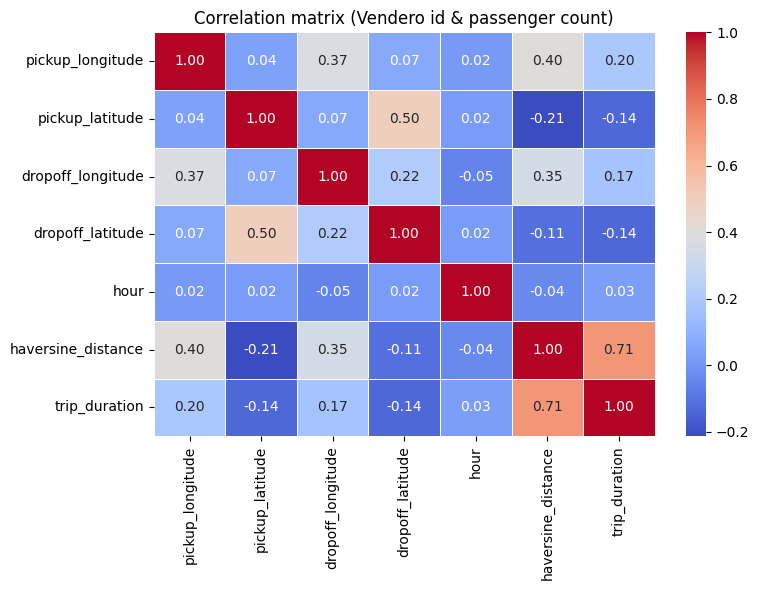

In [530]:
cols = ['pickup_longitude', 
        'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude','hour','haversine_distance', 'trip_duration']
feats = df[cols]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix (Vendero id & passenger count)")
plt.tight_layout()